In [2]:
import numpy as np

X_train = np.load('/content/drive/MyDrive/1. Natural Language Processsing/Khóa luận tốt nghiệp/Word2vec/English/training.npy')
y_train = np.load('/content/drive/MyDrive/1. Natural Language Processsing/Khóa luận tốt nghiệp/Word2vec/English/training_labels.npy')
X_test = np.load('/content/drive/MyDrive/1. Natural Language Processsing/Khóa luận tốt nghiệp/Word2vec/English/test.npy')
y_test = np.load('/content/drive/MyDrive/1. Natural Language Processsing/Khóa luận tốt nghiệp/Word2vec/English/test_labels.npy')
embedding_matrix = np.load('/content/drive/MyDrive/1. Natural Language Processsing/Khóa luận tốt nghiệp/Word2vec/English/embedding_matrix.npy')

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Bidirectional, Dense, Embedding, LSTM, Dropout, Conv1D, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping

vocab_size = 52145

# embedding = Embedding(vocab_size,
#                       output_dim=int(3e2),
#                       weights=[embedding_matrix],
#                       trainable=True)

# Variable-length int sequences.
input = tf.keras.Input(shape=(300,), dtype='int32')

# Embedding lookup.
token_embedding = tf.keras.layers.Embedding(vocab_size,
                                            output_dim=int(3e2),
                                            weights=[embedding_matrix],
                                            trainable=True)
# Query embeddings of shape [batch_size, Tq, dimension].
query_embeddings = token_embedding(input)
# Value embeddings of shape [batch_size, Tv, dimension].
value_embeddings = token_embedding(input)

# CNN layer.
cnn_layer = tf.keras.layers.Conv1D(filters=128,
                                   kernel_size=5,
                                   padding='same')

query_seq_encoding = cnn_layer(query_embeddings)
value_seq_encoding = cnn_layer(value_embeddings)

# Attention layer 1
query_value_attention_seq = tf.keras.layers.Attention()([query_seq_encoding, value_seq_encoding])

query_encoding = tf.keras.layers.GlobalAveragePooling1D()(query_seq_encoding)

query_value_attention = tf.keras.layers.GlobalAveragePooling1D()(query_value_attention_seq)

output_layer1 = tf.keras.layers.Concatenate()([query_encoding, query_value_attention])

# Attention layer 2
query_value_attention_seq2 = tf.keras.layers.Attention()([query_seq_encoding, value_seq_encoding])

query_encoding2 = tf.keras.layers.GlobalAveragePooling1D()(query_seq_encoding)

query_value_attention2 = tf.keras.layers.GlobalAveragePooling1D()(query_value_attention_seq2)

output_layer2 = tf.keras.layers.Concatenate()([query_encoding2, query_value_attention2])

# Attention layer 3
query_value_attention_seq3 = tf.keras.layers.Attention()([query_seq_encoding, value_seq_encoding])

query_encoding3 = tf.keras.layers.GlobalAveragePooling1D()(query_seq_encoding)

query_value_attention3 = tf.keras.layers.GlobalAveragePooling1D()(query_value_attention_seq3)

output_layer3 = tf.keras.layers.Concatenate()([query_encoding3, query_value_attention3])

input_layer = tf.keras.layers.Concatenate()([output_layer1, output_layer2, output_layer3])
clf = Dense(128,activation="relu")(input_layer)
clf = Dense(1,activation="sigmoid")(clf)

model = Model(input, clf)

model.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              metrics=['accuracy'])

model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 300)]                0         []                            
                                                                                                  
 embedding (Embedding)       (None, 300, 300)             1564350   ['input_1[0][0]',             
                                                          0          'input_1[0][0]']             
                                                                                                  
 conv1d (Conv1D)             (None, 300, 128)             192128    ['embedding[0][0]',           
                                                                     'embedding[1][0]']           
                                                                                              

In [4]:
history = model.fit(X_train, y_train,
                    batch_size=1024,
                    epochs=100,
                    verbose=1,
                    validation_split=0.1)


Epoch 1/100
22/22 [==============================] - 22s 670ms/step - loss: 0.6788 - accuracy: 0.6199 - val_loss: 0.7112 - val_accuracy: 0.3704
Epoch 2/100
22/22 [==============================] - 10s 469ms/step - loss: 0.6552 - accuracy: 0.6337 - val_loss: 0.7480 - val_accuracy: 0.2484
Epoch 3/100
22/22 [==============================] - 10s 453ms/step - loss: 0.6385 - accuracy: 0.6434 - val_loss: 0.7360 - val_accuracy: 0.3592
Epoch 4/100
22/22 [==============================] - 9s 423ms/step - loss: 0.6219 - accuracy: 0.6865 - val_loss: 0.7105 - val_accuracy: 0.4732
Epoch 5/100
22/22 [==============================] - 10s 471ms/step - loss: 0.6043 - accuracy: 0.7184 - val_loss: 0.6870 - val_accuracy: 0.5508
Epoch 6/100
22/22 [==============================] - 10s 472ms/step - loss: 0.5854 - accuracy: 0.7438 - val_loss: 0.6509 - val_accuracy: 0.6356
Epoch 7/100
22/22 [==============================] - 10s 435ms/step - loss: 0.5655 - accuracy: 0.7624 - val_loss: 0.6284 - val_accuracy: 

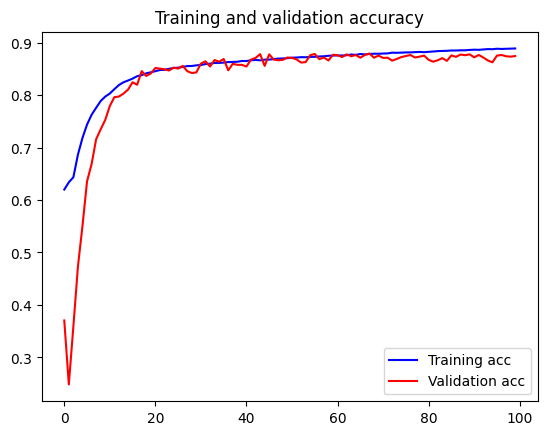

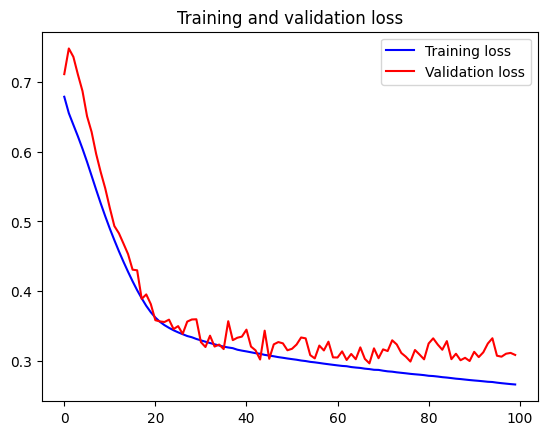

In [5]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [6]:
score = model.evaluate(X_test, y_test, batch_size=1024)
print()
print("ACCURACY:",score[1])
print("LOSS:",score[0])

25/25 [==============================] - 3s 139ms/step - loss: 0.2878 - accuracy: 0.8768

ACCURACY: 0.8767550587654114
LOSS: 0.2878020703792572
